#### CSC 296S Deep Learning (Spring 2026)

#### Dr. Haiquan Chen, Dept of Computer Scicence

#### California State University, Sacramento



## Imports & Functions

In [3]:
import os, csv, re
import librosa
import numpy as np
import soundfile as sf
import random
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import soundfile
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt
import librosa.display
import time

## Data Prep

In [4]:
#seed for data randomization, hard coded for reproducability
SEED = 534
torch.manual_seed(SEED) 
torch.backends.mps.deterministic = True 
torch.backends.mps.benchmark = False

SAMPLE_RATE = 44100
BATCH_SIZE = 32

In [5]:
#filepaths
test_dataframe_live = "../live_test/Test_Dataframe_Live.csv"
training_dataset_csv_path = "../data/Datasets_TTA_Split_A_Weight_dB_SPL_2sec_Aug_Dataset/Train_Dataset.csv"
testing_dataset_csv_path = "../data/Datasets_TTA_Split_A_Weight_dB_SPL_2sec_Aug_Dataset/Test_Dataset.csv"
#training datasets
train_sound_training_data_path = "../data/Datasets_TTA_Split_A_Weight_dB_SPL_2sec_Aug_Dataset/training/train_sounds"
urban_ambient_training_data_path = "../data/Datasets_TTA_Split_A_Weight_dB_SPL_2sec_Aug_Dataset/training/urban_ambient"
#testing datasets
train_sound_testing_data_path = "../data/Datasets_TTA_Split_A_Weight_dB_SPL_2sec_Aug_Dataset/testing/Train"
urban_ambient_testing_data_path = "../data/Datasets_TTA_Split_A_Weight_dB_SPL_2sec_Aug_Dataset/testing/Urban_Ambiente"

## Creating Randomized CSV File and Data Frames

In [6]:
#helper function, sorts audio files into a consistant order when building the csv
def extract_first_two_numbers(file_name):
    #check regex of file name
    match = re.match(r"(\d+)_(\d+)_", file_name)
    #return (38, 1)
    if match:
        first_num, second_num = int(match.group(1)), int(match.group(2))
        return first_num, second_num
    #if filename does not match pattern
    return float('inf'), float('inf')  

In [7]:
#create the CSV files for file accessability

#for training dataset
with open(training_dataset_csv_path, 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter=',')
    writer.writerow(['audio_name', 'label', 'path'])
    
    for path, dirs, files in os.walk(train_sound_training_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)
 
        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'train_sound', full_path])

    for path, dirs, files in os.walk(urban_ambient_training_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)
        
        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'urban_ambient', full_path])

#for testing dataset
with open(testing_dataset_csv_path, 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter=',')
    writer.writerow(['audio_name', 'label', 'path'])
    
    for path, dirs, files in os.walk(train_sound_testing_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)
 
        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'train_sound', full_path])

    for path, dirs, files in os.walk(urban_ambient_testing_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)
        
        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'urban_ambient', full_path])



In [8]:
#training dataset info
dataframe_training = pd.read_csv(training_dataset_csv_path) 
dataframe_training.tail()

,audio_name,label,path
28278,18_29_Amb_Verkehrslaermmessungen.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
28279,18_30_Amb_Verkehrslaermmessungen.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
28280,18_31_Amb_Verkehrslaermmessungen.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
28281,18_32_Amb_Verkehrslaermmessungen.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
28282,18_33_Amb_Verkehrslaermmessungen.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...


In [9]:
#testing dataset info
dataframe_testing = pd.read_csv(testing_dataset_csv_path) 
dataframe_testing.tail()

,audio_name,label,path
6239,1_25_Test_USM_traffic.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
6240,1_26_Test_USM_traffic.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
6241,1_27_Test_USM_traffic.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
6242,1_28_Test_USM_traffic.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...
6243,1_29_Test_USM_traffic.wav,urban_ambient,../data/Datasets_TTA_Split_A_Weight_dB_SPL_2se...


## Shuffle the Datasets Based on Random State Seed

In [10]:
dataframe_training = dataframe_training.sample(frac=1, random_state=SEED).reset_index(drop=False)
dataframe_testing = dataframe_testing.sample(frac=1, random_state=SEED).reset_index(drop=False)

## Create Mel Spectogram

In [11]:
#process 50 spectograms at a time
BATCH_SIZE_FEATURES = 50  
#fast fourier transform window size
NUMBER_FFT = 1024        
#how many samples to advance FFT window each step
HOP_LENGTH = 512   
#how many Mel frequency bands to use
NUMBER_MELS = 128       

NUMBER_MFCC = 20

In [12]:
#function to plot a mel spectogram
def plot_sample_mel_spectrogram(dataframe, index):

    file_path = dataframe.loc[index, 'path']
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    
    start = time.time()
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=NUMBER_FFT, hop_length=HOP_LENGTH, n_mels=NUMBER_MELS)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    end = time.time()
    
    plt.figure(figsize=(10, 6))
    librosa.display.specshow(mel_spectrogram_db, x_axis='time', y_axis='mel', sr=sr, cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')
    plt.show()

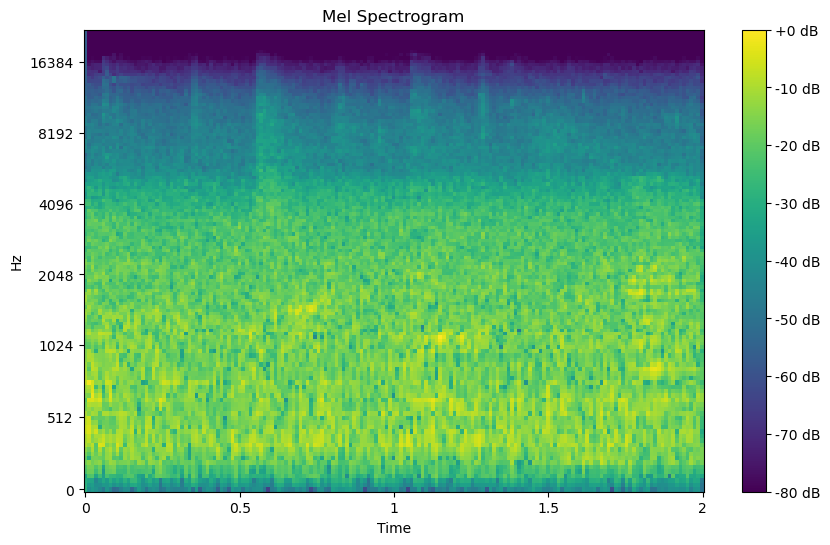

In [13]:
plot_sample_mel_spectrogram(dataframe_training, 165)

In [14]:
#convert every audio file in both datasets into mel spectogram and store in memory
def create_feature_dictionaries_in_batches(dataframe_training, dataframe_testing, batch_size=BATCH_SIZE_FEATURES, sample_rate=SAMPLE_RATE):
    feature_training = {}
    feature_testing = {}
    
    #handle one batch of 50 rows
    def process_batch(batch, hop_length, n_fft, n_mels, sample_rate=SAMPLE_RATE):
        features = {}
        
        for index, row in batch.iterrows():
            file_path = os.path.normpath(row['path'])
            label = row['label']
            try:
                #load in each audio file from it's path using librosa
                audio, sr = librosa.load(file_path, sr=sample_rate)
    
                #generate the mel spectogram
                mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
                #converts from power scale to decibles (easier for the model to learn from)
                mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
                #store result
                features[index] = {
                    "feature": mel_spectrogram_db,
                    "label": label,
                }
            #error handling
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
        return features


    for i in tqdm(range(0, len(dataframe_training), batch_size), desc="Process Training Data in Batches"):
        batch = dataframe_training.iloc[i : i + batch_size]
        batch_features = process_batch(batch, hop_length=HOP_LENGTH, n_fft=NUMBER_FFT, n_mels=NUMBER_MELS, sample_rate=SAMPLE_RATE)
        feature_training.update(batch_features)

    for i in tqdm(range(0, len(dataframe_testing), batch_size), desc="Process Testing Data in Batches"):
        batch = dataframe_testing.iloc[i : i + batch_size]
        batch_features = process_batch(batch, hop_length=HOP_LENGTH, n_fft=NUMBER_FFT, n_mels=NUMBER_MELS, sample_rate=SAMPLE_RATE)
        feature_testing.update(batch_features)

    return feature_training, feature_testing


In [15]:
feature_training, feature_testing = create_feature_dictionaries_in_batches(dataframe_training, dataframe_testing)

Process Testing Data in Batches: 100%|██████████| 125/125 [00:17<00:00,  7.06it/s]


In [16]:
for path in dataframe_training['path']:
    full_path = os.path.abspath(path)
    if not os.path.exists(full_path):
        print(f"file not found - {full_path}")

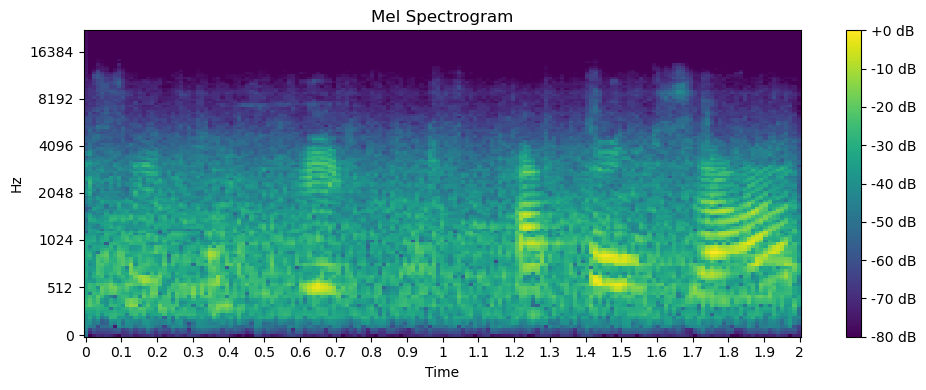

In [17]:
def plot_mel_spectrogramm(features, index):
    mel_spectrogram = features[index]["feature"]
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spectrogram, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')
    plt.tight_layout()
    duration = mel_spectrogram.shape[1] * (HOP_LENGTH / SAMPLE_RATE)
    plt.xticks(np.arange(0, duration, 0.1))
    plt.show()

plot_mel_spectrogramm(feature_testing, 51)

## Loading in Data

In [18]:
#encode string labels to integers: train_sound = 0, urban_ambient = 1
label_encoder = LabelEncoder()
dataframe_training['encoded_label'] = label_encoder.fit_transform(dataframe_training['label'])
dataframe_testing['encoded_label'] = label_encoder.transform(dataframe_testing['label'])

In [22]:
#PyTorch dataset for Mel spectogram audio classification
#Takes a dataframe with labels and a feature dictionary 
class AudioDataset(Dataset):
    """
    PyTorch Dataset for Mel spectrogram audio classification.
    Takes a dataframe (with labels) and a feature dictionary (with precomputed spectrograms)
    and returns (spectrogram_tensor, label_tensor) pairs for the DataLoader.
    """

    def __init__(self, dataframe, feature_dictionary):
        self.dataframe = dataframe
        self.feature_dictionary = feature_dictionary

    def __len__(self):
        #total number of samples in dataset
        return len(self.dataframe)

    def __getitem__(self, index):
        #get the precomputed mel spectrogram and add a channel dimension
        #(128, time) -> (1, 128, time) for cnn input
        feature = torch.tensor(self.feature_dictionary[index]["feature"], dtype=torch.float32).unsqueeze(0)

        #get the integer label (0 or 1)
        encoded_label = torch.tensor(self.dataframe.loc[index, 'encoded_label'], dtype=torch.long)

        return feature, encoded_label
    

In [23]:
#create dataset objects for training and testing
training_dataset = AudioDataset(dataframe_training, feature_training)
testing_dataset  = AudioDataset(dataframe_testing,  feature_testing)

#wrap in DataLoaders
#shuffle=False, already shuffled
#drop_last=True drops the final incomplete batch so every batch is exactly BATCH_SIZE
training_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
testing_loader  = DataLoader(testing_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

#verify shapes: expect (32, 1, 128, ~173) for a 2-second clip
for features, labels in training_loader:
    print(f"Feature batch shape : {features.shape}")
    print(f"Label batch shape   : {labels.shape}")
    break

Feature batch shape : torch.Size([32, 1, 128, 173])
Label batch shape   : torch.Size([32])


## CNN + Transformer Hybrid Model

Architecture overview:
1. CNN frontend
2. Transformer encoder
3. FCNN Classifier head